# Analisis Sentimen Pantai Labuhan Jukung, Lampung. Menggunakan Algoritma Naive Bayes

In [5]:
import pandas as pd
import re

# Panggil Dataset ulasan pantai
df = pd.read_csv(r"C:\Users\ACER\Downloads\ulasan_pan.csv")

# Menampilkan dataset yang telah dipanggil
df


,nama_tempat,user,review,rating
0,unknown location,hairin,"Duduk menikmati ombak di tepi pantai, sambil m...",4
1,unknown location,muhammadsafei,"pantai nya bagus, tapi agak kotor, terakhir ke...",1
2,unknown location,Joseph Gabriel,Pantai Labuhan Jukung merupakan salah satu pan...,5
3,unknown location,mey deb,"Pantainya bersih, pasirnya putih, ada tempat n...",5
4,unknown location,Muhammad Ikhwan,Tiket masuk IDR10.000/motor.\nPantai & Pemanda...,3
...,...,...,...,...
513,unknown location,RAFSANJANI TV (Reza Rafsanjani),Lokasi wisata daerah di lampung barat yang ade...,4
514,unknown location,Agus Priyanto (IYAN),Tempat liburan yg pas untuk kalian² semua.,5
515,unknown location,Ridwan Ridwan,"Rapi dan lumayan bersih, bagus utk foto foto",5
516,unknown location,Laila Fadlia,"Mudah dicapai, gratis, perbanyak wahana permainan",5


In [6]:
# EDA untuk mengetahui karakteristik data

print(f"\nTipe data:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nDuplikat: {df.duplicated().sum()}")


Tipe data:
nama_tempat    object
user           object
review         object
rating          int64
dtype: object

Missing values:
nama_tempat    0
user           0
review         0
rating         0
dtype: int64

Duplikat: 0


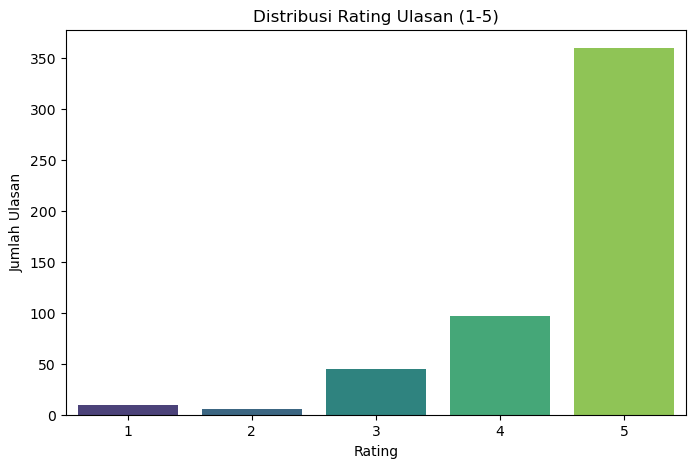

In [12]:
# Melihat Distribusi Dataset

import matplotlib.pyplot as plt
import seaborn as sns

# Visualisasi Distribusi
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='rating', palette='viridis', order=sorted(df['rating'].unique()))
plt.title('Distribusi Rating Ulasan (1-5)')
plt.xlabel('Rating')
plt.ylabel('Jumlah Ulasan')
plt.show()

# Preprocessing Data

In [42]:
# Kamus Stopword
stopword = {
    'dan', 'yang', 'untuk', 'pada', 'ke', 'para', 'namun', 'dengan', 'itu', 'di', 'dari', 'ini', 
    'saya', 'kami', 'karena', 'karna', 'sudah', 'bisa', 'ada', 'juga', 'setelah', 'kurang', 
    'lebih', 'tidak', 'sangat', 'aja', 'sih', 'nih', 'lah', 'pun', 'kok', 'loh',
    'pantai', 'krui', 'lampung', 'tempat', 'kesini', 'disini', 'sini', 'nya',
    'yg', 'd', 'dyg', 'sy', 'tp', 'tpi', 'dgn', 'dg', 'utk', 'bgt', 
    'gak', 'gk', 'ga', 'klo', 'kalo', 'sdh', 'udh', 'udah',
    'jg', 'juga', 'ny', 'si', 'deh', 'dong',
    'dr', 'drpd', 'pd', 'spy', 'krn', 'knp', 'hal',
    'jadi', 'masih', 'sama', 'buat', 'kita', 'saja',
    'tapi', 'kalau', 'seperti', 'semua', 'lagi', 'banyak', 'satu', 'labuhan', 'jukung', 'cocok', 'hanya', 'agak'
}

# Fungsi untuk normalisasi kata
def preprocess(text):
    # Mengisi nilai null
    if pd.isna(text) or not isinstance(text, str):
        return ""
        
    # Case Folding
    text = text.lower()
    
    # Text Cleaning 
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'\@\w+|\#', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Stopword Removal
    words = text.split()
    cleaned_words = [word for word in words if word not in stopword]
    
    # Hapus Spasi
    text = ' '.join(cleaned_words)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['review_clean'] = df['review'].apply(preprocess)


In [43]:
# Pemberian label pada rating
def sentiment(rating):
    if rating <= 3:
        return 'Negatif'
    else:
        return 'Positif'

df['sentiment'] = df['rating'].apply(sentiment)
print(f"Distribusi Rating Ulasan:\n{df['sentiment'].value_counts()}")

Distribusi Rating Ulasan:
sentiment
Positif    457
Negatif     61
Name: count, dtype: int64


# Menerapkan Algoritma Naive Bayes Multinomial

In [44]:
# Naive Bayes Multinomial dipilih karena data yang diolah berbentuk teks
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline

# Membagi Data menjadi data training dan data test
X = df['review_clean']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 80% train, 20% test
    random_state=42,    
    stratify=y          
)

print(f"\nData Training: {len(X_train)}")
print(f"Data Testing: {len(X_test)}")



Data Training: 414
Data Testing: 104


In [26]:
# Definisi pipeline untuk hasil yang lebih konsisten
pipeline = Pipeline([
    ('vectorizer', CountVectorizer(
        max_features=5000,      # fokus pada 5000 kata paling sering muncul
        min_df=2,               # Kata minimal muncul 2 kali
        max_df=0.8              # Abaikan kata yang muncul di > 80% dokumen
    )),
    ('classifier', MultinomialNB(
        alpha=1.0,              
        class_prior=None,       
        fit_prior=True
    ))
])

# Melatih model Naive Bayes Multinomial
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nAkurasi Model: {accuracy:.2%}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)


Akurasi Model: 85.58%

Classification Report:
              precision    recall  f1-score   support

     Negatif       0.20      0.08      0.12        12
     Positif       0.89      0.96      0.92        92

    accuracy                           0.86       104
   macro avg       0.54      0.52      0.52       104
weighted avg       0.81      0.86      0.83       104


Confusion Matrix:
[[ 1 11]
 [ 4 88]]


# Visualisasi

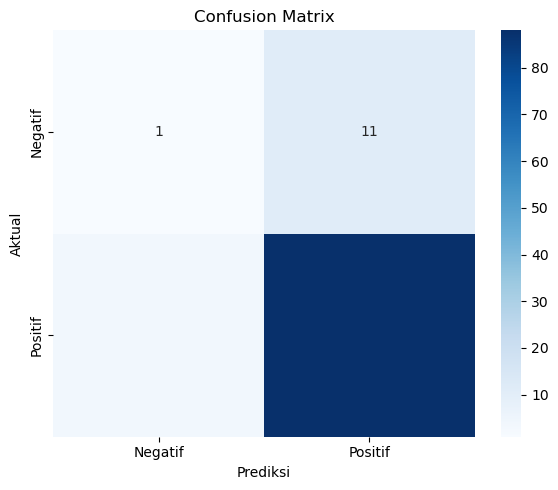

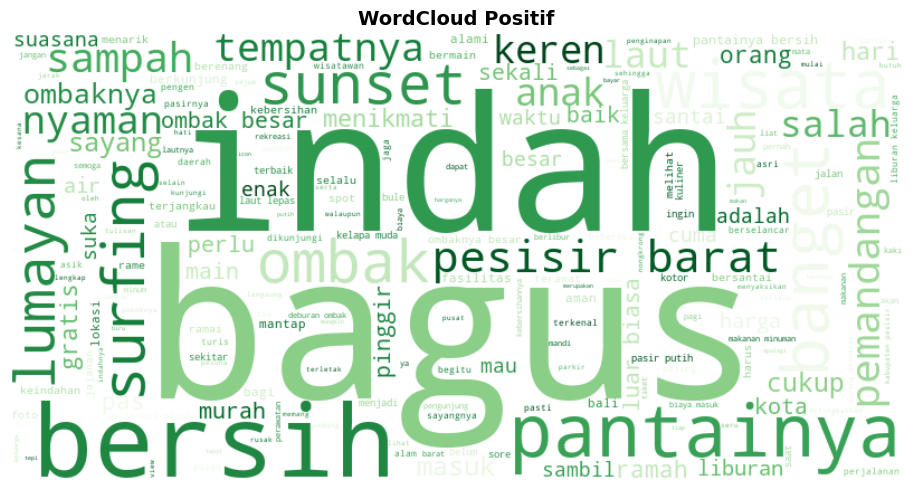

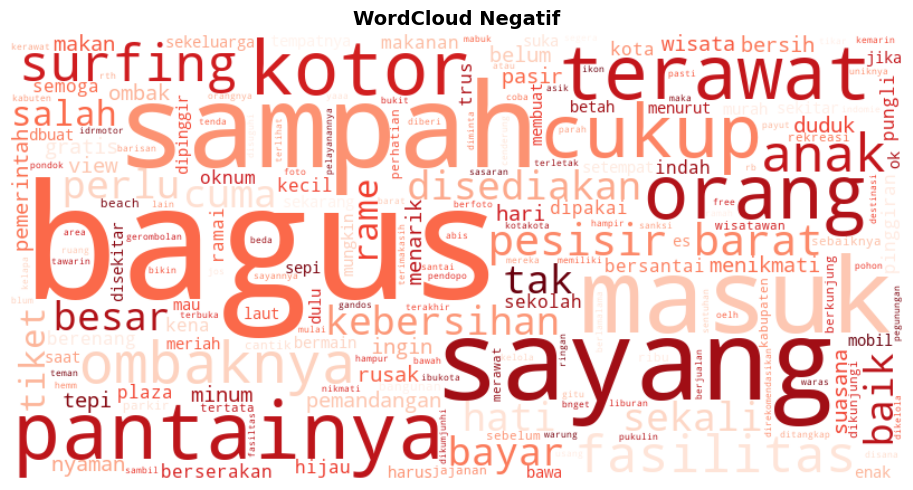

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negatif', 'Positif'],
            yticklabels=['Negatif', 'Positif'])
plt.title('Confusion Matrix')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.show()

# Word Cloud
# Positif
pos_text = ' '.join(df[df['sentiment'] == 'Positif']['review_clean'].dropna())
wc_pos = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(pos_text)

plt.figure(figsize=(10, 5))
plt.imshow(wc_pos, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud Positif', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Negatif
neg_text = ' '.join(df[df['sentiment'] == 'Negatif']['review_clean'].dropna())
wc_neg = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(neg_text)

plt.figure(figsize=(10, 5))
plt.imshow(wc_neg, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud Negatif', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()




In [46]:
from collections import Counter
print("\n10 Kata Teratas - Negatif:")
for word, freq in Counter(neg_text.split()).most_common(10):
    print(f"• {word}: {freq}x")

print("\n10 Kata Teratas - Positif:")
for word, freq in Counter(pos_text.split()).most_common(10):
    print(f"• {word}: {freq}x")


10 Kata Teratas - Negatif:
• bagus: 22x
• sampah: 10x
• sayang: 9x
• masuk: 8x
• pantainya: 8x
• kotor: 7x
• orang: 7x
• terawat: 7x
• cukup: 7x
• ombaknya: 6x

10 Kata Teratas - Positif:
• bagus: 109x
• indah: 89x
• bersih: 62x
• pantainya: 61x
• ombak: 51x
• wisata: 49x
• banget: 40x
• barat: 36x
• pesisir: 33x
• besar: 33x
